<a href="https://colab.research.google.com/github/SunX97/reponew/blob/main/breastcancerdataset_manipalassement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [62]:
df = pd.read_csv('/content/breast-cancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [63]:
# INspect data structures and check missing values
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [64]:
# STEP 1: Load and Pre-process the Local Dataset

df = pd.read_csv('/content/breast-cancer.csv')
if 'id' in df.columns:
    df = df.drop('id', axis=1)

In [65]:
# 1.1 Separating Features and targets
df['diagnosis'] = df['diagnosis'].map({'M': 0, 'B': 1})
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [66]:
# 1.2 Feature Scaling : Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)
print(X_standardized[:5])

[[ 1.09706398e+00 -2.07333501e+00  1.26993369e+00  9.84374905e-01
   1.56846633e+00  3.28351467e+00  2.65287398e+00  2.53247522e+00
   2.21751501e+00  2.25574689e+00  2.48973393e+00 -5.65265059e-01
   2.83303087e+00  2.48757756e+00 -2.14001647e-01  1.31686157e+00
   7.24026158e-01  6.60819941e-01  1.14875667e+00  9.07083081e-01
   1.88668963e+00 -1.35929347e+00  2.30360062e+00  2.00123749e+00
   1.30768627e+00  2.61666502e+00  2.10952635e+00  2.29607613e+00
   2.75062224e+00  1.93701461e+00]
 [ 1.82982061e+00 -3.53632408e-01  1.68595471e+00  1.90870825e+00
  -8.26962447e-01 -4.87071673e-01 -2.38458552e-02  5.48144156e-01
   1.39236330e-03 -8.68652457e-01  4.99254601e-01 -8.76243603e-01
   2.63326966e-01  7.42401948e-01 -6.05350847e-01 -6.92926270e-01
  -4.40780058e-01  2.60162067e-01 -8.05450380e-01 -9.94437403e-02
   1.80592744e+00 -3.69203222e-01  1.53512599e+00  1.89048899e+00
  -3.75611957e-01 -4.30444219e-01 -1.46748968e-01  1.08708430e+00
  -2.43889668e-01  2.81189987e-01]
 [ 1.5

In [67]:
#1.2 Train test and split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42         #reserving 20% of dataset for testing and 80% will go for training
)

In [68]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train,y_train)
pred = model.predict(X_test)
print(pred)

[1 0 0 1 1 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 0
 1 0 1 1 0 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 0 1 0
 1 1 0]


In [69]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_test)

In [76]:
model = LogisticRegression(max_iter=10000) # Increased max_iter to help convergence
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [78]:
pred = model.predict(X_test)
print(pred)

[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 0 0]


In [70]:
# STEP 3: Print test metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
def print_metrics(name, y_true, y_pred):
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}\n")

print_metrics("Decision Tree", y_test, dt_preds)
print_metrics("Logistic Regression", y_test, log_preds)



--- Decision Tree ---
Accuracy:  0.9474
Precision: 0.9577
Recall:    0.9577
F1 Score:  0.9577

--- Logistic Regression ---
Accuracy:  0.9737
Precision: 0.9722
Recall:    0.9859
F1 Score:  0.9790



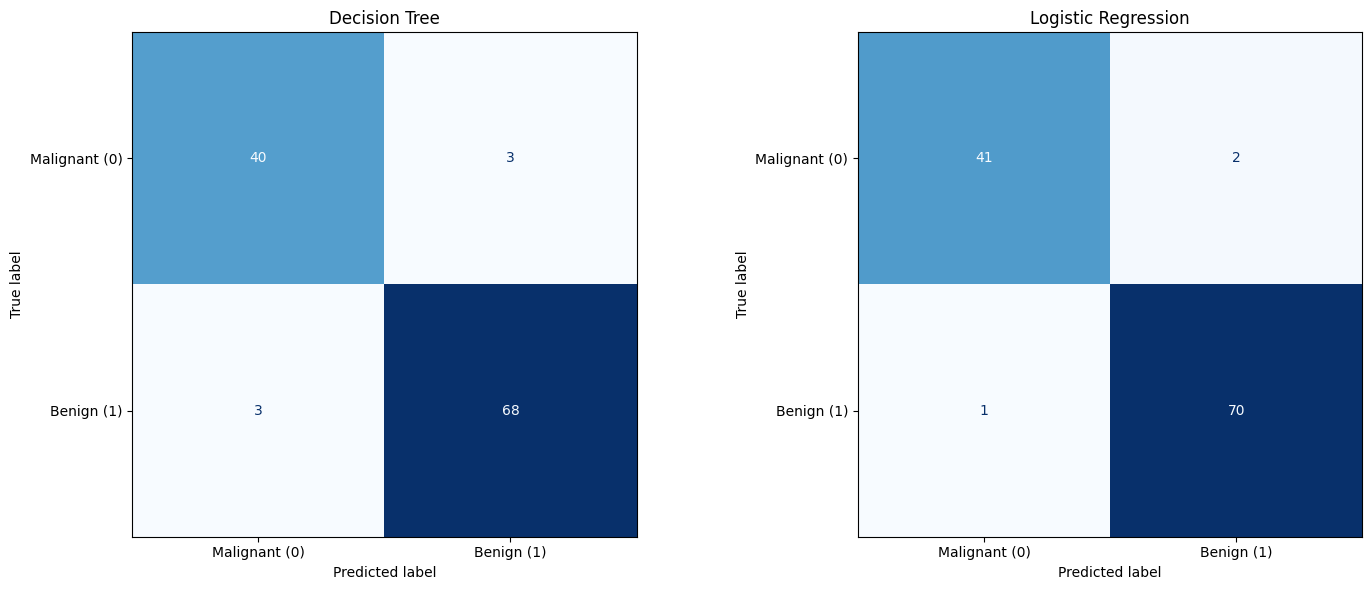

In [73]:
# ---------------------------------------------------------
# STEP 4: Plot Confusion Matrices in a 1x2 Grid
# ---------------------------------------------------------
# Set up a figure with a 1x2 grid
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes = axes.flatten() # Flattens the 1x2 grid into a simple list of 2

models_data = [
    ("Decision Tree", dt_preds, axes[0]),
    ("Logistic Regression", log_preds, axes[1])
]

# Generate a matrix for each model
for title, preds, ax in models_data:
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant (0)', 'Benign (1)'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

--- Final Model Comparison ---
           Decision Tree  Logistic Regression
Accuracy          0.9474               0.9737
Precision         0.9577               0.9722
Recall            0.9577               0.9859
F1 Score          0.9577               0.9790


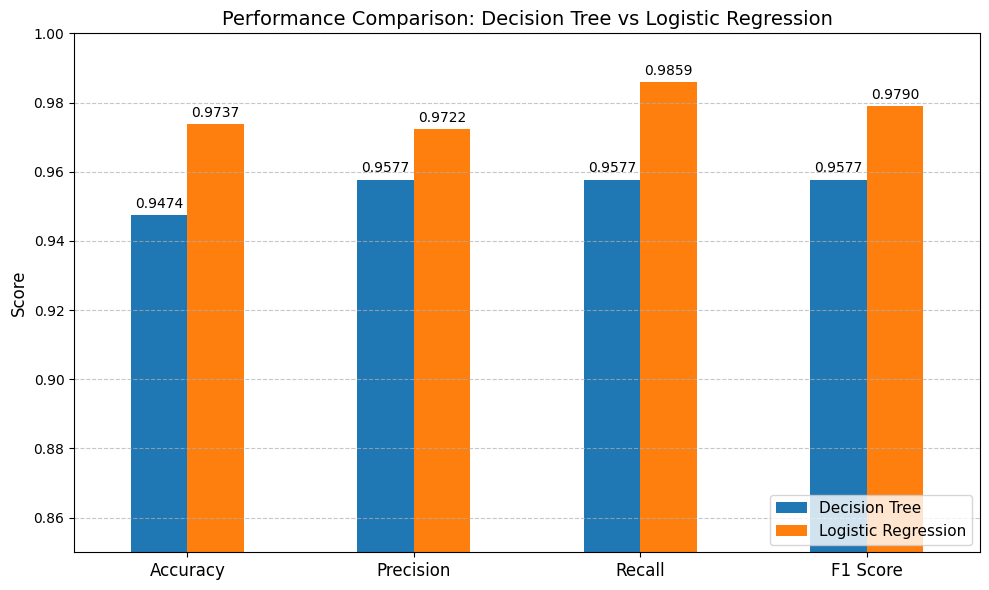

In [82]:
# ---------------------------------------------------------
# STEP 5: Visual Performance Comparison
# ---------------------------------------------------------
# 1. Gather all metrics into lists
dt_metrics = [
    accuracy_score(y_test, dt_preds),
    precision_score(y_test, dt_preds),
    recall_score(y_test, dt_preds),
    f1_score(y_test, dt_preds)
]

log_metrics = [
    accuracy_score(y_test, log_preds),
    precision_score(y_test, log_preds),
    recall_score(y_test, log_preds),
    f1_score(y_test, log_preds)
]

# 2. Create a Pandas DataFrame for a clean table view
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
comparison_df = pd.DataFrame({
    'Decision Tree': dt_metrics,
    'Logistic Regression': log_metrics
}, index=metrics_labels)

print("--- Final Model Comparison ---")
print(comparison_df.round(4)) # Rounds to 4 decimal places for readability

# 3. Plot a grouped bar chart
ax = comparison_df.plot(kind='bar', figsize=(10, 6), color=['#1f77b4', '#ff7f0e'])

# Formatting the chart
plt.title('Performance Comparison: Decision Tree vs Logistic Regression', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.ylim(0.85, 1.0) # Zoomed in between 0.85 and 1.0 to easily see the differences
plt.xticks(rotation=0, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right', fontsize=11)

# Add the exact numbers on top of each bar
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=10)

plt.tight_layout()
plt.show()